# Chapter 6 — Lenses

Companion tutorial for **[Foundations of Computer Vision](https://visionbook.mit.edu/lenses.html)** by Torralba, Isola, and Freeman (MIT Press, 2024).

This is the lens chapter of Part II (Image Formation), and it answers a question pinholes can't: how do you let in more light without sacrificing sharpness? Three ideas drive it:

1. **The lensmaker's formula** turns Snell's law plus a small-angle approximation into one equation, $1/a + 1/b = 1/f$, relating object distance, image distance, and focal length.
2. **Depth of field** falls out of the same geometry: the band of object distances around the focal plane that still appears sharp scales as $D \approx 2NCU^2/f^2$ in the f-number $N$.
3. **A telescope is two lenses sharing a focal point.** A Galilean telescope's angular magnification is $f_1/f_2$, derivable from the same ray-tracing as the lensmaker's formula.

We reproduce the chapter's diagrammatic figures; for the chapter's photographic demos we substitute synthetic versions computed from the same physics. The most interesting bits live in the depth-of-field section, where a Kornia depth-dependent blur recreates the f/2-vs-f/8 comparison from first principles, and at the end, where two of our thin-lens helpers compose into a telescope with no new code.

In [2]:
from pathlib import Path

import torch
import kornia
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Circle, FancyArrowPatch
from matplotlib.collections import LineCollection

# Geometric-optics figures stay device-agnostic; the depth-of-field section
# (which renders per-pixel blur) uses DEVICE to run on GPU when available.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(0)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": False,
})

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)


## 6.2 — Lensmaker's Formula

A lens refracts light at each of its two surfaces. The lensmaker's formula compresses that two-refraction process into one equation,

$$\frac{1}{a} + \frac{1}{b} = \frac{1}{f},$$

relating object distance $a$, image distance $b$, and focal length $f$. We derive it by applying Snell's law twice with the small-angle approximation $\sin\theta \approx \theta$ — the *paraxial* regime where the algebra stays linear (book §6.2).

**Notation for this section.**

| Symbol | Meaning |
|---|---|
| $n$ | Index of refraction of a material. The speed of light in the material is $c/n$, where $c$ is its speed in vacuum. Air is $n = 1$, lens glass is roughly $n = 1.5$. |
| $\theta_1, \theta_2$ | Incidence and refraction angles at a flat interface, measured from the surface normal (Snell's law). |
| $a$ | Distance along the optical axis from an object point to the lens. |
| $b$ | Distance from the lens to the image of that object. |
| $c$ | Height above the optical axis where a ray meets the lens surface. |
| $R$ | Radius of curvature of a spherical lens surface. A full lens has $R_1$ and $R_2$ for its two surfaces. |
| $\theta_S$ | Angle the lens surface makes with the optical axis at height $c$. |
| $f$ | Focal length of the lens. |

Inside the thin-lens derivation, the book labels the four sequential ray angles $\theta_1, \theta_2, \theta_3, \theta_4$ (Table 6.1 of the book). The collision with the Snell-law $\theta_1, \theta_2$ above is the book's notation; we disambiguate by context.

In [4]:
def snells_law(n1, n2, theta1):
    """Refraction angle θ₂ at a flat interface (n₁ sin θ₁ = n₂ sin θ₂).
    
    Angles in radians, measured from the surface normal. Returns NaN past
    the critical angle (total internal reflection).
    """
    n1 = torch.as_tensor(n1, dtype=torch.float32)
    n2 = torch.as_tensor(n2, dtype=torch.float32)
    theta1 = torch.as_tensor(theta1, dtype=torch.float32)
    return torch.asin((n1 / n2) * torch.sin(theta1))


# Sanity check: 30° in air → ≈19.47° in glass (n=1.5).
theta_in = torch.deg2rad(torch.tensor(30.0))
print(f"{torch.rad2deg(snells_law(1.0, 1.5, theta_in)).item():.2f}°")

19.47°


For small angles in radians, $\sin\theta \approx \theta$, and Snell's law at a glass-air interface ($n_1 = 1$, $n_2 = n$) becomes the linear $\theta_1 = n\theta_2$. The book uses this paraxial form throughout the rest of the section.

In [5]:
def surface_angle(c, R):
    """Tilt angle θ_S of a spherical surface at height c, radius R.

    Paraxial form: θ_S ≈ c/R. (Book §6.2, Figure 6.5.)
    """
    c = torch.as_tensor(c, dtype=torch.float32)
    R = torch.as_tensor(R, dtype=torch.float32)
    return c / R


# Sanity check: a spherical surface of radius 50 mm, ray hit at height 5 mm,
# tilts by about 0.1 rad ≈ 5.73°.
print(f"{torch.rad2deg(surface_angle(5.0, 50.0)).item():.2f}°")

5.73°


### The lensmaker's formula in two steps

Applying paraxial Snell's law at the front surface and again at the back, then summing the four angles a ray makes along its path from object to image (book Table 6.1), yields

$$\frac{1}{a} + \frac{1}{b} = (n-1)\left(\frac{1}{R_1} - \frac{1}{R_2}\right).$$

The right-hand side depends only on the lens — its refractive index and the curvatures of its two surfaces. Defining the *focal length* $f$ as

$$\frac{1}{f} = (n-1)\left(\frac{1}{R_1} - \frac{1}{R_2}\right)$$

collapses the relation to the form we set out to derive,

$$\frac{1}{a} + \frac{1}{b} = \frac{1}{f}.$$

Two helpers below: one computes $f$ from a lens's physical parameters; the other solves the conjugate-point relation for the image distance $b$ given an object distance $a$.

In [6]:
def focal_length(n, R1, R2):
    """Focal length of a thin lens via the lensmaker's equation.

    1/f = (n-1) * (1/R1 - 1/R2).  (Book §6.2, Eq. derived from Table 6.1.)
    Sign convention: R > 0 for a surface convex toward incoming light,
    R < 0 for concave. A biconvex lens has R1 > 0 and R2 < 0.
    """
    n = torch.as_tensor(n, dtype=torch.float32)
    R1 = torch.as_tensor(R1, dtype=torch.float32)
    R2 = torch.as_tensor(R2, dtype=torch.float32)
    return 1.0 / ((n - 1.0) * (1.0 / R1 - 1.0 / R2))


def image_distance(a, f):
    """Image distance b from object distance a and focal length f.

    1/a + 1/b = 1/f  =>  b = a*f / (a - f).  (Book §6.2.)
    Returns inf when a == f (object at the focal point → image at infinity).
    """
    a = torch.as_tensor(a, dtype=torch.float32)
    f = torch.as_tensor(f, dtype=torch.float32)
    return a * f / (a - f)


# Sanity check: biconvex lens, glass (n=1.5), surfaces R1=+50 mm and R2=-50 mm.
# Lensmaker's formula gives f = 50 mm. Object at 200 mm should image at 67 mm.
f = focal_length(1.5, 50.0, -50.0)
b = image_distance(200.0, f)
print(f"f = {f.item():.2f} mm, b(a=200) = {b.item():.2f} mm")

f = 50.00 mm, b(a=200) = 66.67 mm


**Figure 6.3(a) — Snell's law at a flat interface.** A ray crosses from a medium with refractive index $n_1$ into a denser medium with $n_2 > n_1$ and bends toward the normal. The angles $\theta_1, \theta_2$ are measured from the normal, and $n_1 \sin\theta_1 = n_2 \sin\theta_2$ relates them. The book's panel (b), a photograph of a straw refracting in a glass of water, is the same physics in the physical world; we don't reproduce the photo here. (Book §6.2, Figure 6.3.)

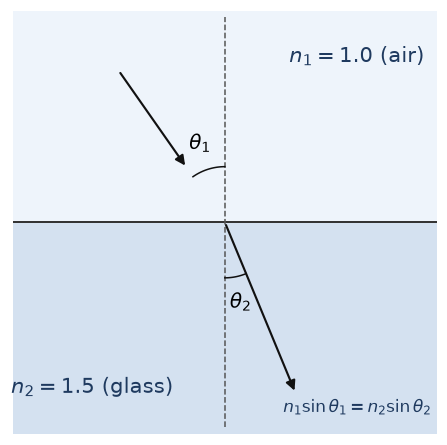

In [12]:
# Figure 6.3 (a) — Snell's law at a flat interface (book §6.2).

# Compute the refraction: a 35-degree ray in air (n1) crosses into glass (n2). Snell's
# law bends it toward the normal -- the effect this figure illustrates.
n1, n2 = 1.0, 1.5
theta1 = torch.deg2rad(torch.tensor(35.0))
theta2 = snells_law(n1, n2, theta1)          # n1 sin θ1 = n2 sin θ2

# Geometry knobs: ray length, the angle-arc radius, the label radius, and how far
# short of the interface the incoming arrowhead stops (so it clears the arc).
ray_len, arc_r, label_r, head_gap = 1.4, 0.42, 0.62, 0.5

# Unit ray directions, both measured from the vertical normal at the origin.
in_dir = torch.stack([torch.sin(theta1), -torch.cos(theta1)])    # down-right toward origin
out_dir = torch.stack([torch.sin(theta2), -torch.cos(theta2)])   # bent toward the normal below

# Endpoints: source up-left, incoming arrowhead short of the interface, refracted tip below.
src = -ray_len * in_dir
head = -head_gap * in_dir
tip = ray_len * out_dir

# Sample each angle arc: upward normal -> incoming ray, and downward normal -> refracted ray.
t = torch.linspace(0.0, 1.0, 60)
arc1 = torch.pi / 2 + t * theta1
arc2 = -torch.pi / 2 + t * theta2
mid1 = torch.pi / 2 + 0.5 * theta1
mid2 = -torch.pi / 2 + 0.5 * theta2

fig, ax = plt.subplots(figsize=(6, 5))

# Two materials: a faint tint for the n1 region above, a deeper tint for the n2 region below.
ax.axhspan(0.0, 1.7, color="#eef4fb", zorder=0)
ax.axhspan(-1.7, 0.0, color="#d4e1f0", zorder=0)

# The flat interface and the dashed surface normal through the point of incidence.
ax.axhline(0.0, color="#333333", lw=1.3, zorder=2)
ax.plot([0.0, 0.0], [-1.55, 1.55], color="#555555", lw=1.0, ls="--", zorder=2)

# Incoming ray: arrowhead lands near the interface but short of contact, leaving room for the arc.
ax.add_patch(FancyArrowPatch((src[0].item(), src[1].item()),
                             (head[0].item(), head[1].item()),
                             arrowstyle="-|>", mutation_scale=13, lw=1.4, color="#111111", zorder=3))
# Refracted ray: leaves the point of incidence with its arrowhead pointing away.
ax.add_patch(FancyArrowPatch((0.0, 0.0), (tip[0].item(), tip[1].item()),
                             arrowstyle="-|>", mutation_scale=13, lw=1.4, color="#111111", zorder=3))

# The two angle arcs at the point of incidence.
ax.plot((arc_r * torch.cos(arc1)).tolist(), (arc_r * torch.sin(arc1)).tolist(),
        color="#111111", lw=1.0, zorder=3)
ax.plot((arc_r * torch.cos(arc2)).tolist(), (arc_r * torch.sin(arc2)).tolist(),
        color="#111111", lw=1.0, zorder=3)

# Angle labels at each arc's midpoint, nudged just outside the arc.
ax.text((label_r * torch.cos(mid1)).item(), (label_r * torch.sin(mid1)).item(),
        r"$\theta_1$", ha="center", va="center", fontsize=13)
ax.text((label_r * torch.cos(mid2)).item(), (label_r * torch.sin(mid2)).item(),
        r"$\theta_2$", ha="center", va="center", fontsize=13)

# Material labels, set in the empty quadrants clear of the rays.
ax.text(1.0, 1.25, r"$n_1 = 1.0$ (air)", ha="center", va="center", fontsize=14, color="#1f3a5f")
ax.text(-1.0, -1.25, r"$n_2 = 1.5$ (glass)", ha="center", va="center", fontsize=14, color="#1f3a5f")

# Snell's law itself, annotated in the open lower-right corner of the denser medium.
ax.text(1.0, -1.4, r"$n_1 \sin\theta_1 = n_2 \sin\theta_2$",
        ha="center", va="center", fontsize=11, color="#1f3a5f")

ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect("equal")
ax.axis("off")

plt.savefig(IMAGES_DIR / "fig06_03a.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure 6.4(a) — Thin-lens geometry.** A point on the optical axis at distance $a$ from the lens emits rays in many directions. Those rays pass through the lens at various heights up to $c$ and converge to a single image point at distance $b$ on the other side. The angle the lowest extreme ray makes with the optical axis is $\theta_1$ on the object side and $\theta_4$ on the image side. The lensmaker's formula derived in this section is the statement that for a thin lens, this convergence happens at the same $b$ for every ray emitted from the same object point. (Book §6.2, Figure 6.4(a).)

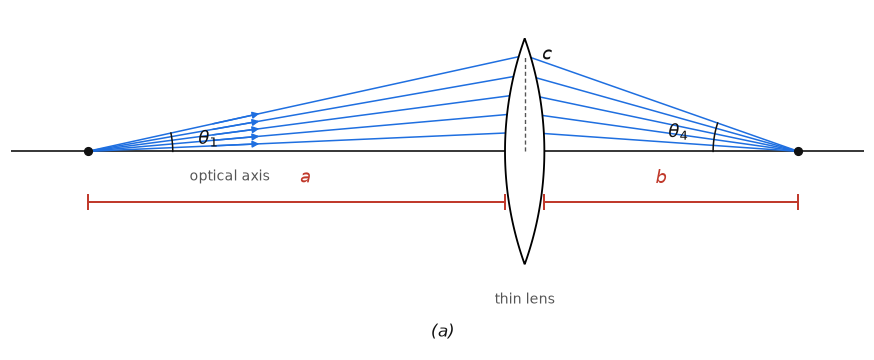

In [23]:
# Figure 6.4 (a) — Thin-lens geometry (book §6.2).

# This cell draws the thin-lens ray diagram (the upper half of the bundle, with the
# optical axis as the lower edge): a fan of rays runs from the object point, through the
# lens at heights up to c, and back to a single image point. It illustrates the premise
# of the lensmaker's formula -- a thin lens reconverges every ray from one object point
# to one image point -- with the extreme ray turning from angle theta_1 to theta_4.

# Object/image distances along the axis; b solves the conjugate relation 1/a + 1/b = 1/f.
a = 4.0
f = 1.54
c = 0.85
b = image_distance(a, f)
b_v = b.item()

# Build the biconvex lens outline as two gentle circular arcs meeting at the rim points
# (0, +/-1) and bulging to +/-t on the axis -- the glass the rays refract through.
t = 0.18
cx = (t ** 2 - 1.0) / (2.0 * t)
R = (cx ** 2 + 1.0) ** 0.5
y_lens = torch.linspace(-1.0, 1.0, 200)
half_thick = cx + torch.sqrt(R ** 2 - y_lens ** 2)
right_edge = torch.stack([half_thick, y_lens], dim=1)
left_edge = torch.stack([-half_thick.flip(0), y_lens.flip(0)], dim=1)
lens_xy = torch.cat([right_edge, left_edge], dim=0)

# Heights at which the upper-half fan crosses the lens, from just above the axis up to c.
ray_heights = torch.linspace(c / 5, c, 5)

# Extreme-ray angles with the axis, computed in torch so the geometry stays device-
# agnostic; the arc samples sweep from the axis up to the extreme ray (theta_1, theta_4).
th1 = torch.atan(torch.tensor(c / a))
th4 = torch.atan(torch.tensor(c / b_v))
s = torch.linspace(0.0, 1.0, 40)
arc1 = s * th1
arc4 = torch.pi - s * th4

blue, dark, gray, red = "#1f6fe0", "#111111", "#555555", "#c0392b"
r_arc = 0.78
fig, ax = plt.subplots(figsize=(10, 4))

# Draw the optical axis across the full width and label it in the empty lower half.
ax.axhline(0.0, color="#000000", lw=1.0, zorder=1)
ax.text(-2.7, -0.16, "optical axis", fontsize=9, color=gray, ha="center", va="top")

# Draw the lens, outlined black and filled white, at x = 0.
ax.add_patch(Polygon(lens_xy.tolist(), closed=True,
                     facecolor="white", edgecolor="#000000", lw=1.2, zorder=3))
ax.text(0.0, -1.25, "thin lens", fontsize=9, color=gray, ha="center", va="top")

# Draw each ray (object point -> lens at height h -> image point) with a small arrowhead
# near the object marking travel direction; together they show all rays reconverging.
for h in ray_heights.tolist():
    ax.plot([-a, 0.0, b_v], [0.0, h, 0.0], color=blue, lw=1.0, zorder=2, solid_capstyle="butt")
    ax.add_patch(FancyArrowPatch((a * (0.28 - 1.0), 0.28 * h), (a * (0.40 - 1.0), 0.40 * h),
                                 arrowstyle="-|>", mutation_scale=9, color=blue, lw=1.0, zorder=2))

# Mark the object and image points: one source point reimaged to one point.
ax.plot([-a, b_v], [0.0, 0.0], "o", color=dark, markersize=5, linestyle="none", zorder=5)

# Mark the extreme ray height c at the lens plane (dashed) and label it at the top ray.
ax.plot([0.0, 0.0], [0.0, c], color=gray, lw=0.9, ls=(0, (3, 2)), zorder=4)
ax.text(0.16, c, r"$c$", fontsize=12, color=dark, ha="left", va="center")

# Draw the angle arcs of the extreme ray: theta_1 where it leaves the object, theta_4
# where it reaches the image.
ax.plot((-a + r_arc * torch.cos(arc1)).tolist(), (r_arc * torch.sin(arc1)).tolist(),
        color=dark, lw=1.0, zorder=4)
ax.text((-a + (r_arc + 0.24) * torch.cos(th1 / 2)).item(),
        ((r_arc + 0.24) * torch.sin(th1 / 2)).item(),
        r"$\theta_1$", fontsize=12, color=dark, ha="left", va="center")
ax.plot((b_v + r_arc * torch.cos(arc4)).tolist(), (r_arc * torch.sin(arc4)).tolist(),
        color=dark, lw=1.0, zorder=4)
ax.text((b_v + (r_arc + 0.24) * torch.cos(torch.pi - th4 / 2)).item(),
        ((r_arc + 0.24) * torch.sin(torch.pi - th4 / 2)).item(),
        r"$\theta_4$", fontsize=12, color=dark, ha="right", va="center")

# Draw two distance brackets below the axis, split by a gap at the lens so the collinear
# a- and b- segments read as two brackets: object distance a, image distance b.
br_y, tick, gap = -0.45, 0.06, 0.18
ax.plot([-a, -gap], [br_y, br_y], color=red, lw=1.3, zorder=4)
ax.plot([-a, -a], [br_y - tick, br_y + tick], color=red, lw=1.3, zorder=4)
ax.plot([-gap, -gap], [br_y - tick, br_y + tick], color=red, lw=1.3, zorder=4)
ax.text(-2.0, -0.32, r"$a$", fontsize=12, color=red, ha="center", va="bottom")
ax.plot([gap, b_v], [br_y, br_y], color=red, lw=1.3, zorder=4)
ax.plot([gap, gap], [br_y - tick, br_y + tick], color=red, lw=1.3, zorder=4)
ax.plot([b_v, b_v], [br_y - tick, br_y + tick], color=red, lw=1.3, zorder=4)
ax.text(b_v / 2, -0.32, r"$b$", fontsize=12, color=red, ha="center", va="bottom")

# Panel label.
ax.text((-a + b_v) / 2, -1.6, "(a)", fontsize=11, style="italic", color=dark, ha="center", va="center")

ax.set_xlim(-4.7, 3.1)
ax.set_ylim(-1.75, 1.25)
ax.axis("off")

plt.savefig(IMAGES_DIR / "fig06_04a.png", dpi=150, bbox_inches="tight")
plt.show()

The figure depicts an idealization: rays appear to bend at a single point (the center of the lens) rather than refracting twice (at each glass surface). This is the *thin-lens approximation*, which assumes the lens's physical thickness is small enough to ignore. Panel (b), drawn next, distorts the geometry to expose the actual two-surface bending that the thin-lens approximation glosses over.